<h2>BERCHES, CHARLES ANDREI</h2>
<h2>BSIT-3A</h2>

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
accidents = pd.read_csv('uk_road_accident.csv')

In [3]:
accidents

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,5/6/2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,2/7/2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26-08-2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16-08-2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,3/9/2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,18-02-2022,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car
660675,201091NM01881,Slight,21-02-2022,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660676,201091NM01935,Slight,23-02-2022,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660677,201091NM01964,Serious,23-02-2022,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc


In [4]:
accidents['Accident Date'] = accidents['Accident Date'].str.strip()

accidents['Accident Date'] = accidents['Accident Date'].astype('str')

accidents['Accident Date'] = accidents['Accident Date'].str.replace('/', '-')

accidents['Accident Date'] = pd.to_datetime(accidents['Accident Date'], dayfirst=True, errors='coerce')

In [6]:
accidents['Latitude'] = accidents['Latitude'].fillna(accidents['Latitude'].mode()[0])
accidents['Longitude'] = accidents['Longitude'].fillna(accidents['Longitude'].mode()[0])
accidents['Road_Surface_Conditions'] = accidents['Road_Surface_Conditions'].fillna('unaccounted')
accidents['Road_Type'] = accidents['Road_Type'].fillna('unaccounted')
accidents['Urban_or_Rural_Area'] = accidents['Urban_or_Rural_Area'].fillna('unaccounted')
accidents['Weather_Conditions'] = accidents['Weather_Conditions'].fillna(accidents['Weather_Conditions'].mode()[0])

In [5]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  object        
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660654 non-null  float64       
 4   Light_Conditions         660679 non-null  object        
 5   District Area            660679 non-null  object        
 6   Longitude                660653 non-null  float64       
 7   Number_of_Casualties     660679 non-null  int64         
 8   Number_of_Vehicles       660679 non-null  int64         
 9   Road_Surface_Conditions  659953 non-null  object        
 10  Road_Type                656159 non-null  object        
 11  Urban_or_Rural_Area      660664 non-null  object        
 12  Weather_Conditio

<h1>Univariate Data Analytics</h1>

1. How many accidents fall under each severity category?

In [10]:
accidents['Accident_Severity'].value_counts()

Accident_Severity
Slight     563801
Serious     88217
Fatal        8661
Name: count, dtype: int64

<h2>Insight #1</h2>

<p>Most accidents were <b>slight</b>, making up about 563,801(85%) of all cases. <b>Serious</b> accidents were less common, around 88,217(13%), and <b>fatal</b> accidents were the rarest, at just over 8,661(1%).</p>
<hr>
<h2>Insight #2</h2>

<p>Most accidents are <b>slight</b>, but <b>serious</b> and <b>fatal</b> ones still make up about 15% of all cases. This means that even though they don’t happen as often, severe accidents are still a big concern and may need special road safety actions.</p>
<hr>

2. What weather patterns are most commonly observed during accidents?

In [11]:
accidents['Weather_Conditions'].value_counts()

Weather_Conditions
Fine no high winds       535013
Raining no high winds     79696
Other                     17150
Raining + high winds       9615
Fine + high winds          8554
Snowing no high winds      6238
Fog or mist                3528
Snowing + high winds        885
Name: count, dtype: int64

<h2>Insight #3</h2>

<p>Most accidents happened when the weather was <b>fine with no high winds</b>. The next most common condition was <b>rain without high winds</b>. Bad weather like <b>fog</b>, <b>snow</b>, and <b>high winds</b> was much less common during accidents.</p>
<hr>
<h2>Insight #4</h2>

<p>Even though bad weather conditions like <b>fog</b>, <b>snow</b>, or <b>high winds</b> are often seen as dangerous, most accidents still happened in <b>fine</b> weather. This could mean that drivers may take more risks or pay less attention when the weather seems safe.</p>
<hr>
<h2>Insight #5</h2>
<p><b>Rain</b> was involved in a noticeable number of accidents, especially when there were <b>no high winds</b>. This suggests that even light rain can make roads more dangerous and affect driving conditions.</p>
<hr>

<h1>Bivariate Data Analytics</h1>

3. What is the correlation between vehicle count and casualty numbers in accidents?

In [15]:
accidents[['Number_of_Vehicles', 'Number_of_Casualties']].corr()

,Number_of_Vehicles,Number_of_Casualties
Number_of_Vehicles,1.000000,0.228889
Number_of_Casualties,0.228889,1.000000


<h2>Insight #6</h2>

<p>The correlation between the <b>number of vehicles</b> and the <b>number of casualties</b> is about <b>0.23</b>, which is a low positive relationship. This means that as the number of vehicles increases, the number of casualties tends to increase a little bit, but the connection is <b>weak</b>.</p>
<hr>
<h2>Insight #7</h2>

<p>The connection between the number of vehicles and casualties is <b>weak</b>,  meaning other factors like speed, road conditions, or type of crash might be more important in causing injuries.</p>
<hr>

4. What's the differences in vehicle types across different districts?

In [22]:
accidents.groupby('District Area')['Vehicle_Type'].value_counts().unstack().fillna(0)

Vehicle_Type,Agricultural vehicle,Bus or coach (17 or more pass seats),Car,Data missing or out of range,Goods 7.5 tonnes mgw and over,Goods over 3.5t. and under 7.5t,Minibus (8 - 16 passenger seats),Motorcycle 125cc and under,Motorcycle 50cc and under,Motorcycle over 125cc and up to 500cc,Motorcycle over 500cc,Other vehicle,Pedal cycle,Ridden horse,Taxi/Private hire car,Van / Goods 3.5 tonnes mgw or under
District Area,,,,,,,,,,,,,,,,
Aberdeen City,2.0,93.0,950.0,0.0,35.0,8.0,6.0,23.0,7.0,35.0,31.0,12.0,0.0,0.0,20.0,101.0
Aberdeenshire,1.0,119.0,1400.0,0.0,54.0,13.0,7.0,39.0,14.0,50.0,41.0,13.0,1.0,0.0,32.0,146.0
Adur,3.0,29.0,480.0,0.0,13.0,4.0,1.0,14.0,7.0,9.0,21.0,3.0,0.0,0.0,8.0,27.0
Allerdale,1.0,39.0,839.0,0.0,21.0,13.0,3.0,30.0,14.0,11.0,49.0,16.0,0.0,0.0,38.0,54.0
Alnwick,4.0,8.0,168.0,0.0,7.0,4.0,0.0,7.0,4.0,2.0,5.0,3.0,0.0,0.0,8.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,1.0,85.0,961.0,0.0,22.0,15.0,4.0,51.0,11.0,20.0,67.0,13.0,0.0,0.0,35.0,76.0
Wycombe,14.0,29.0,1293.0,0.0,53.0,21.0,2.0,31.0,15.0,22.0,98.0,21.0,0.0,0.0,25.0,105.0
Wyre,2.0,49.0,930.0,0.0,29.0,13.0,5.0,29.0,14.0,17.0,45.0,15.0,0.0,0.0,30.0,60.0


<h2>Insight #8</h2>

<p><b>Aberdeen City</b> has <b>950</b>, while <b>Aberdeenshire</b> has <b>1400 cars</b>, and <b>Wycombe</b> has <b>1293 cars</b>. Motorcycles, buses, and other vehicles also vary from one district to another.</p>
<hr>

5. How do vehicle types contribute to each level of accident severity?

In [24]:
accidents.groupby('Accident_Severity')['Vehicle_Type'].value_counts().unstack().fillna(0)

Vehicle_Type,Agricultural vehicle,Bus or coach (17 or more pass seats),Car,Data missing or out of range,Goods 7.5 tonnes mgw and over,Goods over 3.5t. and under 7.5t,Minibus (8 - 16 passenger seats),Motorcycle 125cc and under,Motorcycle 50cc and under,Motorcycle over 125cc and up to 500cc,Motorcycle over 500cc,Other vehicle,Pedal cycle,Ridden horse,Taxi/Private hire car,Van / Goods 3.5 tonnes mgw or under
Accident_Severity,,,,,,,,,,,,,,,,
Fatal,21.0,325.0,6577.0,0.0,216.0,67.0,29.0,189.0,95.0,105.0,339.0,70.0,6.0,0.0,155.0,467.0
Serious,282.0,3373.0,66461.0,0.0,2321.0,857.0,276.0,2031.0,1014.0,1014.0,3457.0,767.0,39.0,0.0,1771.0,4554.0
Slight,1644.0,22180.0,424954.0,6.0,14770.0,5172.0,1671.0,13049.0,6494.0,6537.0,21861.0,4800.0,152.0,4.0,11368.0,29139.0


<h2>Insight #9</h2>

<p><b>Cars</b> are the most common vehicle type involved in accidents across all severity levels. <b>Motorcycles</b>, especially larger ones, show a higher share in <b>serious</b> and <b>slight</b> accidents, <b>buses</b> and other vehicles appear less often, and overall, <b>slight</b> accidents are far more frequent than <b>serious</b> or <b>fatal</b> ones for every vehicle type.</p>
<hr>
<h2>Insight #10</h2>

<p><b>Fatal</b> accidents are spread across many vehicle types, but compared to <b>cars</b>, <b>motorcycles</b> and <b>other vehicles</b> have a higher proportion of severe outcomes, suggesting these vehicles carry greater risk when accidents occur.</p>
<hr>

<h1>Multivariate Data Analytics</h1>

6. What is the average number of casualties by accident severity and light condition?

In [28]:
accidents.groupby(['Accident_Severity', 'Light_Conditions'])['Number_of_Casualties'].mean()

Accident_Severity  Light_Conditions           
Fatal              Darkness - lighting unknown    1.676471
                   Darkness - lights lit          1.839247
                   Darkness - lights unlit        1.688889
                   Darkness - no lighting         2.085608
                   Daylight                       1.873522
Serious            Darkness - lighting unknown    1.433249
                   Darkness - lights lit          1.455672
                   Darkness - lights unlit        1.438889
                   Darkness - no lighting         1.799972
                   Daylight                       1.432265
Slight             Darkness - lighting unknown    1.284063
                   Darkness - lights lit          1.346070
                   Darkness - lights unlit        1.305426
                   Darkness - no lighting         1.446372
                   Daylight                       1.320517
Name: Number_of_Casualties, dtype: float64

<h2>Insight #11</h2>

<p><b>Fatal</b> accidents have the highest average <b>number of casualties</b>, especially in <b>darkness with no lighting</b>, where the average is about <b>2</b> people hurt. <b>Serious</b> accidents have fewer casualties on average, around <b>1.4 to 1.8</b> people, depending on the light conditions. <b>Slight</b> accidents usually have the lowest average casualties, about <b>1.3 to 1.4</b> people, no matter the lighting.</p>
<hr>
<h2>Insight #12</h2>

<p>Accidents in <b>darkness with no lighting</b> tend to have more casualties on average across all severity levels. This suggests <b>no lighting</b> makes accidents more dangerous, leading to more people getting hurt.</p>
<hr>

<h2>Insight #13</h2>

<p><b>Daylight</b> conditions generally have lower average casualties compared to <b>darkness</b> conditions for each accident severity. This suggests that better visibility during the day might help reduce the number of people injured in accidents.</p>
<hr>

7. Which vehicle types cause the most casualties under different severity levels?

In [29]:
accidents.groupby(['Vehicle_Type', 'Accident_Severity'])['Number_of_Casualties'].sum().unstack().fillna(0)

Accident_Severity,Fatal,Serious,Slight
Vehicle_Type,,,
Agricultural vehicle,37.0,416.0,2160.0
Bus or coach (17 or more pass seats),683.0,4964.0,29268.0
Car,12442.0,97688.0,566562.0
Data missing or out of range,0.0,0.0,9.0
Goods 7.5 tonnes mgw and over,405.0,3351.0,19641.0
Goods over 3.5t. and under 7.5t,145.0,1308.0,6855.0
Minibus (8 - 16 passenger seats),73.0,375.0,2211.0
Motorcycle 125cc and under,334.0,2935.0,17079.0
Motorcycle 50cc and under,164.0,1428.0,8575.0


<h2>Insight #14</h2>

<p><b>Cars</b> cause the most <b>fatal</b>, <b>serious</b>, and <b>slight</b>, followed by <b>vans</b>, <b>buses</b>, and <b>motorcycles</b> depending on the severity level.</p>
<hr>
<h2>Insight #15</h2>

<p><b>Motorcycles</b>, despite having fewer vehicles on the road compared to <b>cars</b>, account for a disproportionately high number of <b>serious</b> and <b>fatal</b> casualties relative to <b>slight</b> severity.</p>
<hr>

8. What is the average number of casualties per accident for each month?

In [60]:
accidents['Month'] = accidents['Accident Date'].dt.month

accidents.groupby('Month')['Number_of_Casualties'].mean()

Month
1     1.343585
2     1.343941
3     1.351107
4     1.364796
5     1.362791
6     1.350826
7     1.366350
8     1.396324
9     1.347144
10    1.347801
11    1.348024
12    1.362972
Name: Number_of_Casualties, dtype: float64

<h2>Insight #16</h2>

<p>The average number of casualties per accident is similar each month, staying around <b>1.34 to 1.40</b>. The highest average is in <b>August</b><b><</b> with about <b>1.40</b> casualties per accident, and the lowest is in <b>January</b> with about <b>1.34.</b></p>
<hr>

9. How many accidents and casualties happened each year?

In [72]:
accidents['Year'] = accidents['Accident Date'].dt.year

accidents.groupby('Year')['Index'].count().reset_index()

,Year,Index
0,2019,182115
1,2020,170591
2,2021,163554
3,2022,144419


In [71]:
accidents.groupby('Year')['Number_of_Casualties'].sum().reset_index()

,Year,Number_of_Casualties
0,2019,247780
1,2020,230905
2,2021,222146
3,2022,195737


<h2>Insight #17</h2>

<p>The <b>number of accidents</b> and the <b>number of casualties</b> show a steady decline from <b>2019 to 2022.</b> In <b>2019</b>, there were <b>182,115</b> accidents leading to <b>247,780</b> casualties, while in <b>2022</b> the numbers dropped to <b>144,419</b> accidents and <b>195,737</b> casualties.</p>
<hr>

10. How many cars were involved in accidents on a dry road surface and caused casualties in the year 2019?

In [80]:
year2019 = accidents[accidents['Year'] == 2019]
drySurfaceWithCasualties = year2019[(year2019['Road_Surface_Conditions'] == 'Dry') & 
                                    (year2019['Number_of_Casualties'] > 0) &
                                    (year2019['Vehicle_Type'] == 'Car')]

drySurfaceWithCasualties['Number_of_Vehicles'].sum()

np.int64(165114)

<h2>Insight #18</h2>

<p>In 2019, a total of 165,114 cars were involved in accidents on dry road surfaces that caused casualties.</p>
<hr>

11. On which day of the week and which day of the month do the most accidents happen, and what are the total casualties for each combination?

In [84]:
accidents['Day'] = accidents['Accident Date'].dt.day
accidents['DayOfWeek'] = accidents['Accident Date'].dt.dayofweek

accidents.groupby(['DayOfWeek', 'Day']).size().unstack()

Day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
DayOfWeek,,,,,,,,,,,,,,,,,,,,,
0,2494,2085,2085,2779,2283,2528,2690,2420,2098,2069,...,2450,2306,2024,2568,2008,2631,2657,2320,1872,1510
1,4139,3192,2823,2636,3652,2763,3273,3665,3153,2991,...,3534,3214,2716,2524,3453,2516,3014,3161,2775,1262
2,3454,3875,3278,2984,2790,4226,2798,3493,3884,3359,...,3273,3676,3277,2694,2711,3699,2347,3249,3277,1406
3,2772,3321,3658,3449,2918,2688,3754,2902,3678,4129,...,2770,3339,3545,3265,2641,2581,3886,2684,3107,1893
4,3852,2682,3302,3810,3306,2869,2551,3803,2766,3487,...,3895,2710,3285,3329,3440,2709,2564,3167,2503,1719
5,3094,4134,2915,3616,4423,3556,3295,2908,4233,2927,...,3082,4243,2920,3274,3960,3561,3254,3005,3535,1824
6,2801,2526,3479,2425,3037,3344,3070,2723,2440,3366,...,2630,2509,3534,2295,2955,3341,2985,2552,2504,2202


In [90]:
accidents.groupby(['DayOfWeek', 'Day'])['Number_of_Casualties'].sum().unstack()

Day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
DayOfWeek,,,,,,,,,,,,,,,,,,,,,
0,3606,3028,3061,4011,3322,3692,3899,3606,3111,2960,...,3587,3451,3025,3815,3002,3881,4060,3466,2693,2162
1,5475,4177,3800,3526,4873,3689,4407,4798,4206,3865,...,4682,4274,3702,3409,4634,3475,4124,4179,3652,1750
2,4604,5060,4334,3866,3637,5582,3758,4591,5089,4431,...,4294,4824,4318,3614,3609,4905,3153,4269,4328,1843
3,3626,4401,4980,4581,3795,3497,4841,3792,4876,5406,...,3694,4407,4653,4344,3615,3379,5128,3620,4173,2531
4,5157,3521,4363,5031,4353,3718,3272,4976,3727,4542,...,5128,3613,4284,4420,4558,3565,3379,4217,3335,2388
5,4123,5561,3860,4817,5982,4834,4462,3916,5747,4018,...,4163,5650,3970,4459,5394,4786,4484,4039,4765,2460
6,4077,3560,4914,3477,4275,4631,4406,3904,3444,4692,...,3739,3629,5056,3242,4179,4699,4337,3697,3590,3181


<h2>Insight #19</h2>

<p>From the data, we can see that <b>Fridays</b> and <b>Saturdays</b> have the highest <b>number of accidents and casualties</b>, while <b>Sundays</b> generally have <b>fewer accidents and casualties</b> compared to weekdays. This means that road crashes are more common and more harmful toward the end of the week, likely because of heavier traffic and more social travel.</p>
<hr>

12. Which day of the month has the highest average number of casualties per accident?

In [89]:
accidentsPerDay = accidents.groupby('Day').size()

casualtiesPerDay = accidents.groupby('Day')['Number_of_Casualties'].sum()

averageCasualties = casualtiesPerDay / accidentsPerDay
averageCasualties

Day
1     1.356631
2     1.343479
3     1.360817
4     1.350707
5     1.349324
6     1.349003
7     1.355280
8     1.349959
9     1.357181
10    1.339753
11    1.360885
12    1.353301
13    1.357032
14    1.354941
15    1.346595
16    1.354178
17    1.351178
18    1.357291
19    1.354163
20    1.360289
21    1.361351
22    1.353749
23    1.356912
24    1.361814
25    1.368640
26    1.369567
27    1.363723
28    1.384314
29    1.364932
30    1.355745
31    1.380755
dtype: float64

<h2>Insight #20</h2>

<p>The <b>26th</b> day of the month has the highest average number of casualties per accident, with an average of <b>1.3696</b>. This means that, on average, accidents on the <b>26th</b> result in slightly more injuries than on any other day.</p>
<hr>

Distribution of accident severity by weather condition

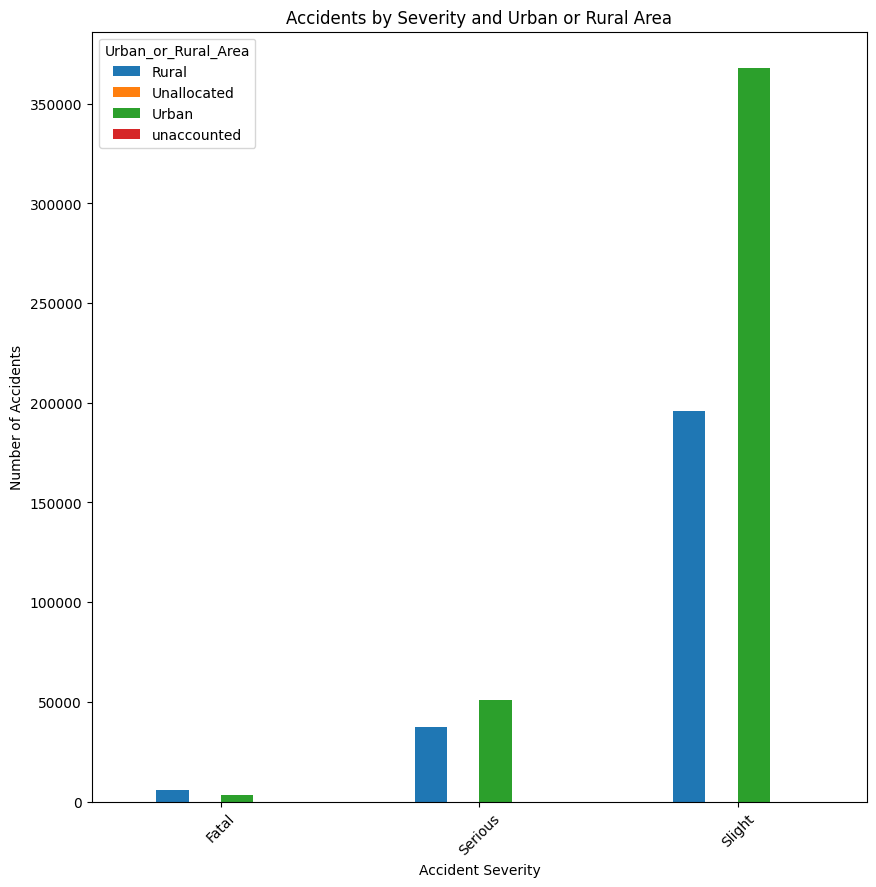

In [96]:
x = accidents.groupby(['Accident_Severity', 'Urban_or_Rural_Area']).size()

x = x.unstack()

x.plot(kind='bar',
       figsize=(10, 10),
       xlabel='Accident Severity', 
       ylabel='Number of Accidents',
       title='Accidents by Severity and Urban or Rural Area')
plt.xticks(rotation=45)
plt.show()

<h2>Insight #21</h2>

<p><b>Urban areas</b> have far more accidents overall, especially for <b>slight</b> injuries, compared to <b>rural areas.</b></p>
<hr>
<h2>Insight #22</h2>

<p><b>Fatal</b> accidents are higher in <b>rural areas</b> than in <b>urban areas</b>, even though <b>rural areas</b> have fewer accidents overall.</p>
<hr>
<h2>Insight #23</h2>

<p>The majority of accidents in both <b>rural and urban areas</b> are <b>slight</b>, showing that most crashes are not severe.</p>
<hr>
<h2>Insight #24</h2>

<p>The chart shows that <b>urban areas</b> have more accidents but <b>rural areas</b> have deadlier ones, possibly due to higher speeds and less immediate medical response in rural regions.</p>
<hr>
<h2>Insight #25</h2>

<p><b>Serious</b> accidents are fairly close between <b>rural and urban areas</b>, but <b>urban areas</b> still have a <b>slight</b> edge.</p>
<hr>